# 52 Random Forest 2

Versión simplificada del modelo Random Forest sobre `sale` y `rent`.

- Features fijas definidas manualmente (todas ya numéricas/binarias)
- Búsqueda de hiperparámetros con `RandomizedSearchCV` + CV=5
- Sin exportar resultados, todo se muestra en el notebook

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split

# ── Configuración ─────────────────────────────────────────────────────────────
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
TARGET_COL    = "log_precio"   # Variable objetivo (está en la lista de features pero es el target)
N_ITER_SEARCH = 40             # Combinaciones a probar en la búsqueda de hiperparámetros
N_SPLITS      = 5              # Folds de validación cruzada

# ── Rutas de los datasets ─────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encontró {name}: {path}")

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets listos:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv


In [5]:
# ── Lista de features ─────────────────────────────────────────────────────────

FEATURES = [
    "log_superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "ratio_dormitorios_superficie",
    "latitud_2",
    "longitud_2",
    "interaccion_latitud_longitud",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # Municipios: columnas binarias (1 = el inmueble está en ese municipio)
    # Las que no existen en un dataset concreto se filtran automáticamente
    "municipio_Ampuero",
    "municipio_Barcena de Cicero",
    "municipio_Camargo",
    "municipio_Cartes",
    "municipio_Castro-Urdiales",
    "municipio_Colindres",
    "municipio_Cudon",
    "municipio_El Astillero",
    "municipio_Entrambasaguas",
    "municipio_Gallarta",
    "municipio_Getxo",
    "municipio_Guarnizo",
    "municipio_Guriezo",
    "municipio_Laredo",
    "municipio_Liendo",
    "municipio_Limpias",
    "municipio_Marina de Cudeyo",
    "municipio_Miengo",
    "municipio_Noja",
    "municipio_Piélagos",
    "municipio_Polanco",
    "municipio_Ramales de la Victoria",
    "municipio_Reocin",
    "municipio_Ribamontan al Mar",
    "municipio_Santa Cruz de Bezana",
    "municipio_Santa Maria de Cayon",
    "municipio_Santander",
    "municipio_Santillana del Mar",
    "municipio_Santoña",
    "municipio_Santurtzi",
    "municipio_Sobremazas",
    "municipio_Solares",
    "municipio_Suances",
    "municipio_Torrelavega",
    "municipio_Villaescusa",
    "municipio_Villapresente",
    "municipio_Viveda",
    "municipio_Voto",
]


def get_metrics(y_real, y_pred) -> pd.DataFrame:
    """Calcula y devuelve un DataFrame con las métricas de evaluación del modelo."""
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(mse,  5)],
        "RMSE": [round(rmse, 5)],
        "MAE":  [round(mae,  5)],
        "R2":   [round(r2,   5)],
        "MAPE": [round(mape, 5)],
    })


DATASET: SALE
Features usadas: 55 | No disponibles en este dataset: 3
  Ausentes: ['municipio_Sobremazas', 'municipio_Villaescusa', 'municipio_Viveda']
Train: 470 filas | Test: 118 filas

Buscando mejores hiperparámetros (40 combinaciones, CV=5)...

Mejores hiperparámetros:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  n_estimators: 200

Métricas en TRAIN:
    MSE    RMSE     MAE      R2    MAPE
0.01586 0.12592 0.08841 0.95147 0.00721

Métricas en TEST:
    MSE    RMSE     MAE      R2    MAPE
0.08841 0.29734 0.20706 0.67528 0.01686


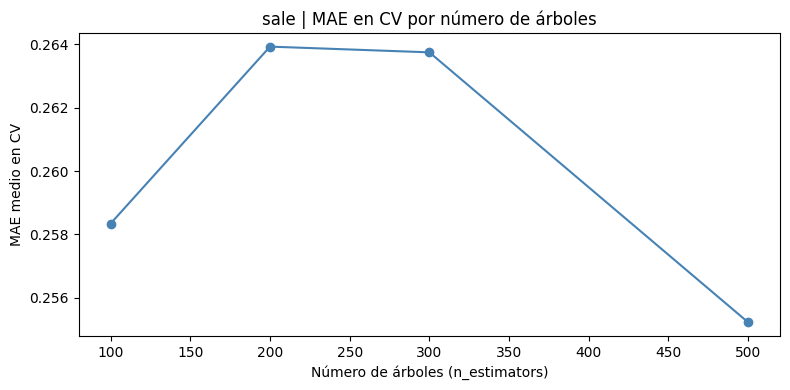


Top 15 features por importancia:
                      feature  importance
 log_superficie_construida_m2     0.15282
                 numero_banos     0.07665
       distancia_min_playa_km     0.07204
           numero_dormitorios     0.06550
 ratio_dormitorios_superficie     0.05111
 ratio_dormitorios_superficie     0.04876
                 tiene_garaje     0.04711
     score_cercania_servicios     0.04514
       ratio_banos_superficie     0.03952
                    latitud_2     0.03857
distancia_min_supermercado_km     0.03815
                      latitud     0.03806
     distancia_min_colegio_km     0.03800
                     longitud     0.03605
 interaccion_latitud_longitud     0.03568

DATASET: RENT
Features usadas: 58 | No disponibles en este dataset: 0
Train: 381 filas | Test: 96 filas

Buscando mejores hiperparámetros (40 combinaciones, CV=5)...

Mejores hiperparámetros:
  max_depth: 10
  max_features: 0.4
  min_samples_leaf: 1
  n_estimators: 500

Métricas en TRAIN:
   

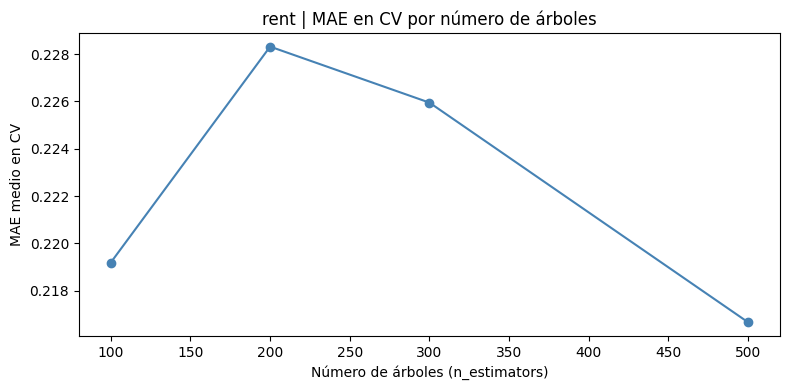


Top 15 features por importancia:
                      feature  importance
 log_superficie_construida_m2     0.20043
             municipio_Laredo     0.12513
                    latitud_2     0.06039
           numero_dormitorios     0.05935
                      latitud     0.05526
       distancia_min_playa_km     0.05027
                   longitud_2     0.04788
                     longitud     0.04720
 interaccion_latitud_longitud     0.04285
     score_cercania_servicios     0.03896
     distancia_min_colegio_km     0.03640
distancia_centro_municipio_km     0.03558
 ratio_dormitorios_superficie     0.03498
       ratio_banos_superficie     0.03491
                 numero_banos     0.03422


In [6]:
# Espacio de búsqueda de hiperparámetros
PARAM_DIST = {
    "n_estimators":      [100, 200, 300, 500],     # Número de árboles
    "max_depth":         [6, 10, 15, 20, None],    # Profundidad máxima (None = sin límite)
    "min_samples_leaf":  [1, 5, 10],               # Mínimo de muestras por hoja
    "max_features":      ["sqrt", 0.4, 0.6],       # Features por árbol
}

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 80)
    print(f"DATASET: {dataset_name.upper()}")

    # ── Carga y selección de features ────────────────────────────────────────
    df = pd.read_csv(dataset_path)

    # Filtrar a features que realmente existen en este dataset
    features_ok = [f for f in FEATURES if f in df.columns]
    features_missing = [f for f in FEATURES if f not in df.columns]

    print(f"Features usadas: {len(features_ok)} | No disponibles en este dataset: {len(features_missing)}")
    if features_missing:
        print(f"  Ausentes: {features_missing}")

    # Eliminar filas sin target
    df = df[df[TARGET_COL].notna()].copy()

    X = df[features_ok].copy()
    y = df[TARGET_COL].copy()

    # ── Imputación de valores faltantes ──────────────────────────────────────
    # Se imputa la mediana de cada columna para no perder filas por NaN
    imputer = SimpleImputer(strategy="median")
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # ── Split train / test ────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X_imp, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} filas | Test: {len(X_test)} filas")

    # ── Búsqueda de hiperparámetros ───────────────────────────────────────────
    # RandomizedSearchCV prueba N_ITER_SEARCH combinaciones aleatorias del espacio
    # y selecciona la que minimiza el MAE en validación cruzada (5 folds)
    print(f"\nBuscando mejores hiperparámetros ({N_ITER_SEARCH} combinaciones, CV={N_SPLITS})...")
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        PARAM_DIST,
        n_iter=N_ITER_SEARCH,
        cv=kf,
        scoring="neg_mean_absolute_error",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,   # reentrena automáticamente con los mejores params sobre X_train completo
    )
    search.fit(X_train, y_train)

    print("\nMejores hiperparámetros:")
    for k, v in sorted(search.best_params_.items()):
        print(f"  {k}: {v}")

    # ── Métricas ──────────────────────────────────────────────────────────────
    rf = search.best_estimator_
    print("\nMétricas en TRAIN:")
    print(get_metrics(y_train, rf.predict(X_train)).to_string(index=False))
    print("\nMétricas en TEST:")
    print(get_metrics(y_test, rf.predict(X_test)).to_string(index=False))

    # ── Gráfico: MAE en CV por n_estimators ───────────────────────────────────
    # Agrupa los resultados del search por n_estimators y muestra el MAE medio
    # (permite ver si más árboles mejoran el modelo)
    cv_results = pd.DataFrame(search.cv_results_)
    cv_results["mae_cv"] = -cv_results["mean_test_score"]
    cv_results["n_estimators"] = cv_results["param_n_estimators"].astype(int)

    mae_by_n = cv_results.groupby("n_estimators")["mae_cv"].mean().sort_index()

    plt.figure(figsize=(8, 4))
    plt.plot(mae_by_n.index, mae_by_n.values, "-o", color="steelblue")
    plt.xlabel("Número de árboles (n_estimators)")
    plt.ylabel("MAE medio en CV")
    plt.title(f"{dataset_name} | MAE en CV por número de árboles")
    plt.tight_layout()
    plt.show()

    # ── Top 15 importancias ───────────────────────────────────────────────────
    importances = (
        pd.DataFrame({"feature": X_train.columns, "importance": rf.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(15)
    )
    print("\nTop 15 features por importancia:")
    print(importances.round(5).to_string(index=False))